# Effective Ripple With NEO-JAX

## What you will learn
How effective ripple compresses low-collisionality neoclassical transport into a profile useful for optimization.

## Codes used
`NEO_JAX` in research mode; cached educational epsilon-effective curves by default.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
`03_epsilon_eff_comparison.png` and `03_epsilon_eff_sensitivity.png`.

## What this teaches

The object is a scalar neoclassical screen: effective ripple as a cheap warning metric for optimization.

## What this does not prove

It does not prove a new NEO_JAX transport calculation or a validated W7-X/HSX prediction.

## Literature anchor

W7-X is the classroom reference for why effective ripple matters: the experiment was designed to reduce the geometry-driven neoclassical loss channel, and later analysis connected record stellarator performance to that optimization. In this notebook, effective ripple is therefore treated as a screen and a design metric, not as the full transport story.

Reading: Beidler et al., *Nature* 596, 221-226 (2021), https://www.nature.com/articles/s41586-021-03687-w.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Learning frame

This notebook is a deliberately small project: define one metric, produce one plot, expose one failure mode, and identify where a real code would enter.

In [5]:
from sos2026.neo_helpers import epsilon_eff_curves, epsilon_sensitivity
from sos2026.plotting import savefig, caption

## 2. Load or generate the teaching data

Cached mode uses small arrays so the conceptual workflow is always available.

In [6]:
curves = epsilon_eff_curves()
curve_df = pd.DataFrame({k: v for k, v in curves.items()})
curve_df.head()

,s,HSX QHS screening metric,W7-X standard screening metric,classical stellarator reference
0,0.030000,0.006393,0.005510,0.025893
1,0.042278,0.006561,0.005512,0.026347
2,0.054557,0.006732,0.005512,0.026830
3,0.066835,0.006905,0.005510,0.027334
4,0.079114,0.007079,0.005506,0.027858


## 3. Make the primary plot

Every plot has a one-sentence caption because students should know how to read it without guessing.

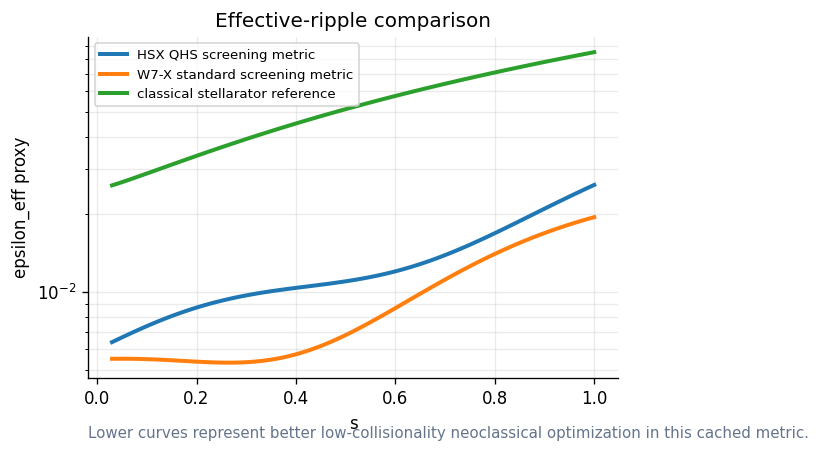

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.9))
for key, value in curves.items():
    if key != "s":
        ax.plot(curves["s"], value, lw=2.4, label=key)
ax.set_yscale("log")
ax.set_xlabel("s")
ax.set_ylabel("epsilon_eff proxy")
ax.set_title("Effective-ripple comparison")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.25)
caption(ax, "Lower curves represent better low-collisionality neoclassical optimization in this cached metric.")
savefig(fig, "03_epsilon_eff_comparison.png")
plt.show()

## 4. Probe the metric

A metric becomes useful for optimization only when we understand how it changes across design choices.

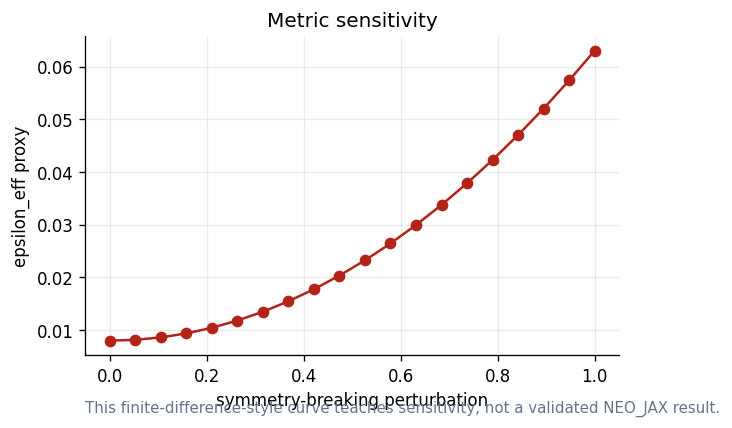

Approx derivative near small perturbation: 0.005789473684210525


In [8]:
strengths, eps = epsilon_sensitivity()
fig, ax = plt.subplots(figsize=(6.0, 3.7))
ax.plot(strengths, eps, marker="o", color="#b42318")
ax.set_xlabel("symmetry-breaking perturbation")
ax.set_ylabel("epsilon_eff proxy")
ax.set_title("Metric sensitivity")
ax.grid(alpha=0.25)
caption(ax, "This finite-difference-style curve teaches sensitivity, not a validated NEO_JAX result.")
savefig(fig, "03_epsilon_eff_sensitivity.png")
plt.show()
print("Approx derivative near small perturbation:", np.gradient(eps, strengths)[1])

## 5. Interpret the design consequence

The table below translates the plot into an optimization decision.

In [9]:
metric_ladder = pd.DataFrame({
    "fidelity": ["Boozer residual", "epsilon-effective", "DKE transport", "experiment"],
    "cost": ["low", "low-medium", "medium-high", "highest"],
    "role": ["early screen", "neoclassical screen", "validation", "truth gate"],
})
metric_ladder

,fidelity,cost,role
0,Boozer residual,low,early screen
1,epsilon-effective,low-medium,neoclassical screen
2,DKE transport,medium-high,validation
3,experiment,highest,truth gate


## 6. Failure mode

The cached plot is useful only if we say what it does not prove.

In [10]:
failure_mode = pd.DataFrame({
    "cached_mode_proves": ["workflow shape", "plot grammar", "where the metric enters"],
    "cached_mode_does_not_prove": ["validated physics", "final design ranking", "runtime scalability"],
})
failure_mode

,cached_mode_proves,cached_mode_does_not_prove
0,workflow shape,validated physics
1,plot grammar,final design ranking
2,where the metric enters,runtime scalability


## 7. Research-mode hook

Run this cell only after timing the package on the lecture machine.

In [11]:
if RUN_MODE == "research":
    import neo_jax
    print("NEO_JAX import OK:", getattr(neo_jax, "__version__", "unknown"))
else:
    print("Cached mode: research package path skipped intentionally.")

Cached mode: research package path skipped intentionally.


## 8. Mini project handoff

Use this notebook during the lecture as the computational project slide points to: change one parameter, regenerate one plot, and explain one design tradeoff.

In [12]:
project_steps = pd.DataFrame({
    "step": [1, 2, 3, 4],
    "action": ["identify metric", "change one input", "regenerate plot", "state failure mode"],
})
project_steps

,step,action
0,1,identify metric
1,2,change one input
2,3,regenerate plot
3,4,state failure mode


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

,case,edge_value,profile_average
1,W7-X standard screening metric,0.0195,0.009299
0,HSX QHS screening metric,0.0260,0.012867
2,classical stellarator reference,0.0850,0.053104


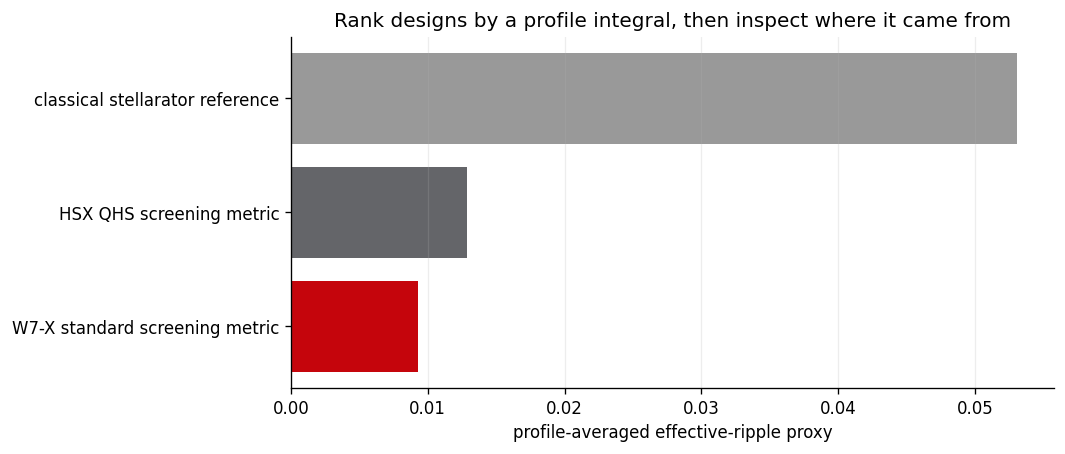

Caption: scalar rankings are useful, but the previous profile plot explains why the ranking occurs.


In [13]:
from sos2026.neo_helpers import epsilon_eff_curves
curves = epsilon_eff_curves()
summary = []
for name, values in curves.items():
    if name == "s":
        continue
    summary.append({"case": name, "edge_value": values[-1], "profile_average": np.trapezoid(values, curves["s"]) / (curves["s"][-1] - curves["s"][0])})
ripple_summary = pd.DataFrame(summary).sort_values("profile_average")
display(ripple_summary)
fig, ax = plt.subplots(figsize=(8.2, 3.8))
ax.barh(ripple_summary["case"], ripple_summary["profile_average"], color=["#c5050c", "#646569", "#999999"][:len(ripple_summary)])
ax.set_xlabel("profile-averaged effective-ripple proxy")
ax.set_title("Rank designs by a profile integral, then inspect where it came from")
ax.grid(axis="x", alpha=0.22)
plt.show()
print("Caption: scalar rankings are useful, but the previous profile plot explains why the ranking occurs.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Change one scalar or one row in the cached data and regenerate the primary plot.

## Expected qualitative answer
The plot should move in a physically interpretable direction, but the cached result remains an educational proxy.

## Research extension
Replace the cached data source with the corresponding real package output after timing and API verification.